In [1]:
from contextlib import nullcontext, redirect_stdout
from pathlib import Path
import gc
import io
import warnings

import numpy as np
import torch
from IPython.display import display
from omegaconf import OmegaConf
from PIL import Image, ImageDraw

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent

import sys
sys.path.insert(0, str(ROOT))

from src.build.model import build_base, wrap_lora
from src.data.letterbox import prepare_image, restore_logit

cfg = OmegaConf.merge(
    OmegaConf.load(ROOT / 'config/tune.yaml'),
    OmegaConf.load(ROOT / 'config/model.yaml'),
)
cfg.birefnet.weight = str(ROOT / cfg.birefnet.weight)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image = np.asarray(Image.open(ROOT / 'asset/sample.webp').convert('RGB'))
input_tensor, _, geometry = prepare_image(
    image, size=int(cfg.data.size), mode=str(cfg.data.mode)
)
input_tensor = torch.from_numpy(input_tensor[None]).to(device)


In [2]:
def run(use_lora):
    with redirect_stdout(io.StringIO()):
        base = build_base(cfg).to(device).eval()
        model = wrap_lora(cfg, base).eval() if use_lora else base
    autocast = (
        torch.amp.autocast('cuda', dtype=torch.float16)
        if device.type == 'cuda'
        else nullcontext()
    )
    with torch.inference_mode(), autocast:
        output = model(input_tensor)
        logit = (output.preds if use_lora else output)[-1][0, 0].float().cpu().numpy()
    probability = 1.0 / (1.0 + np.exp(-np.clip(restore_logit(logit, geometry), -80, 80)))
    mask = (probability >= 0.5).astype(np.uint8) * 255
    del model, base
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return mask

birefnet_mask = run(False)
lora_birefnet_mask = run(True)
assert np.array_equal(birefnet_mask, lora_birefnet_mask)


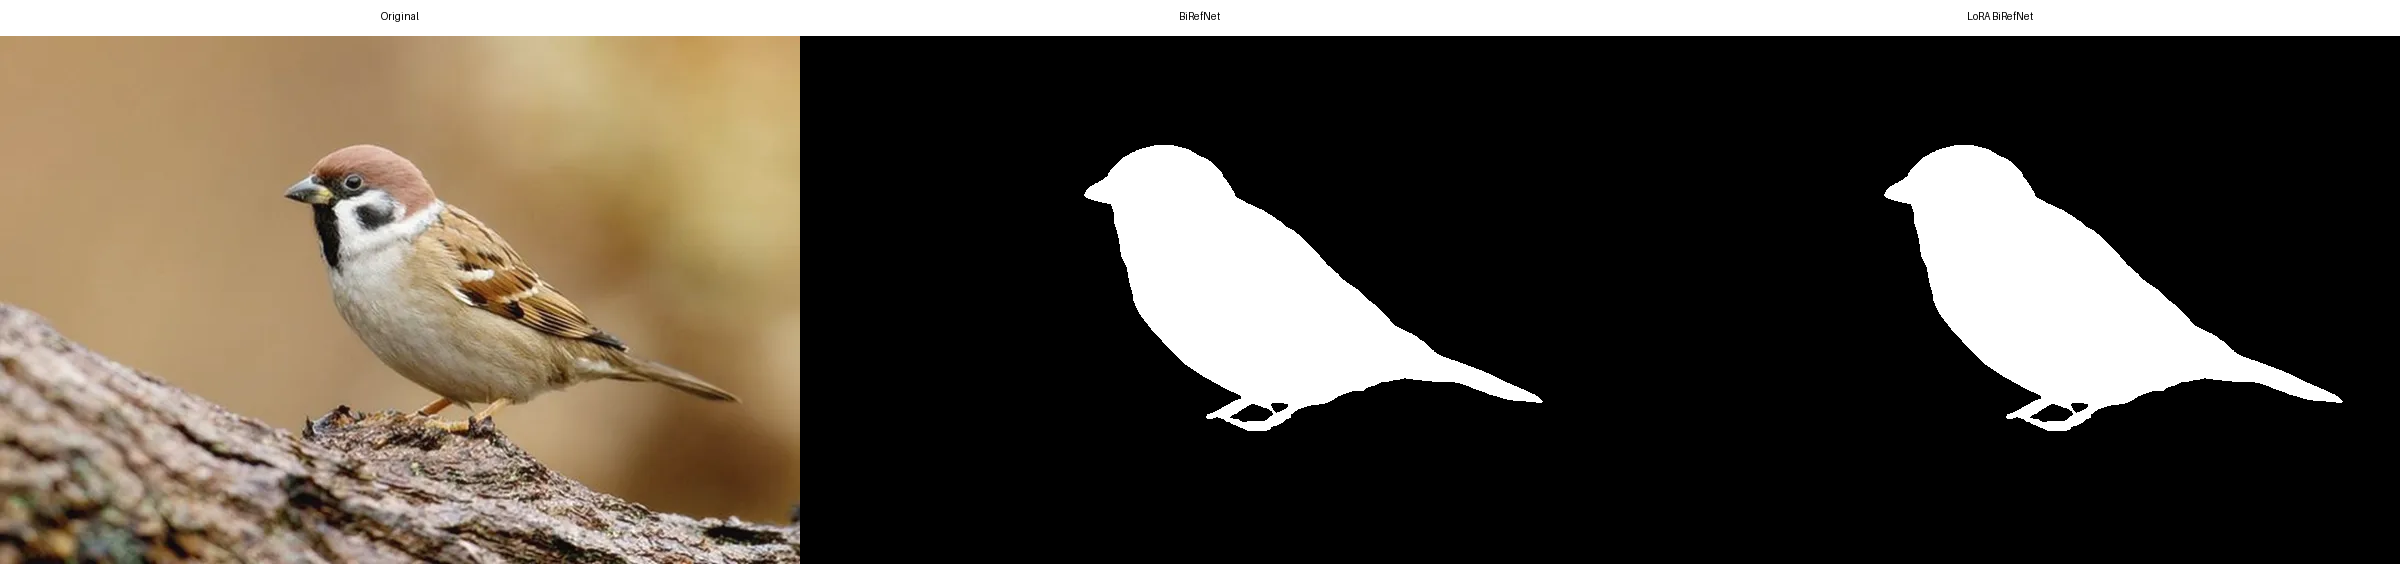

In [12]:
panels = [
    Image.fromarray(image),
    Image.fromarray(birefnet_mask).convert('RGB'),
    Image.fromarray(lora_birefnet_mask).convert('RGB'),
]
titles = ['Original', 'BiRefNet', 'LoRA BiRefNet']
height, width = image.shape[:2]
canvas = Image.new('RGB', (width * 3, height + 36), 'white')
draw = ImageDraw.Draw(canvas)
for index, (panel, title) in enumerate(zip(panels, titles)):
    canvas.paste(panel, (index * width, 36))
    box = draw.textbbox((0, 0), title)
    text_width = box[2] - box[0]
    draw.text((index * width + (width - text_width) // 2, 10), title, fill='black')
display(canvas)
